In [1]:
# enable all interactive output to be 'printed'
# and disable scrolling so long output can be displayed w/o scroll bars

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:


# Step 1: Import Necessary Libraries

# Import necessary libraries for image processing and augmentation
import os
import numpy as np
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# tensorflow and keras modules are used for deep learning model building and image preprocessing


In [6]:

extract_path = os.getcwd() + '\elephant_dataset'

# Step 2: Define Directory Paths

# Define paths to your training and validation (testing) datasets.
# In your case, you will have a 'train' and 'validation' directory where images are stored.
#train_dir = ""  # Replace with your actual train folder path
#test_dir = ""  # Replace with your actual validation\test folder path

train_dir = Path(extract_path) / "train"
test_dir = Path(extract_path) / "test"

# Print the contents
print("Training data folders:", os.listdir(train_dir))
print("Testing data folders:", os.listdir(test_dir))

# These directories should have two subfolders: 'asian' and 'african'


Training data folders: ['African', 'Asian']
Testing data folders: ['African', 'Asian']


In [7]:
# Step 3: Resize and Normalize Images

# To ensure uniformity and improve model performance, we will resize the images to a fixed size and normalize the pixel values.

image_size = (150, 150)  # Resize the images to 150x150 pixels
batch_size = 32          # Batch size for training and validation

# By resizing, we reduce the image dimensions and ensure all images are the same size.

# Normalization (scaling pixel values between 0 and 1) will be done through ImageDataGenerator
# This helps in speeding up convergence during model training.


In [8]:
# Step 4: Set Up Image Data Generators

# Keras' ImageDataGenerator is used for:
# 1. Rescaling pixel values
# 2. Real-time data augmentation (which helps prevent overfitting)
# 3. Loading images in batches for training and validation

# Create an ImageDataGenerator instance for the training data, including augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize the images by dividing pixel values by 255 (to scale between 0 and 1)
    rotation_range=40,     # Randomly rotate images by 0 to 40 degrees
    width_shift_range=0.2, # Shift images horizontally by 20% of the total width
    height_shift_range=0.2,# Shift images vertically by 20% of the total height
    shear_range=0.2,       # Apply shearing transformation to images
    zoom_range=0.2,        # Randomly zoom the images
    horizontal_flip=True,  # Flip images horizontally for data augmentation
    fill_mode='nearest'    # Fill missing pixels after transformation with nearest pixel values
)

# Create a validation data generator (we don't want augmentation here, only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerator created")

ImageDataGenerator created


In [9]:
# Step 5: Load Images from Directories

# Using flow_from_directory to load and preprocess images from the directory
# This function will automatically categorize images based on the folder names ('asian', 'african').

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,     # Path to the train directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for the data
    class_mode='binary'      # Since this is a binary classification task (Asian vs African elephants)
)

val_generator = val_datagen.flow_from_directory(
    directory=test_dir,       # Path to the validation directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for validation data
    class_mode='binary'      # Binary classification (either 'asian' or 'african')
)

(print(type(val_generator)))

# flow_from_directory automatically labels the data based on the folder structure.
# Make sure the folder structure in 'train_dir' and 'val_dir' looks like:
#   train/
#       asian/
#       african/
#   validation/
#       asian/
#       african/


Found 1010 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>


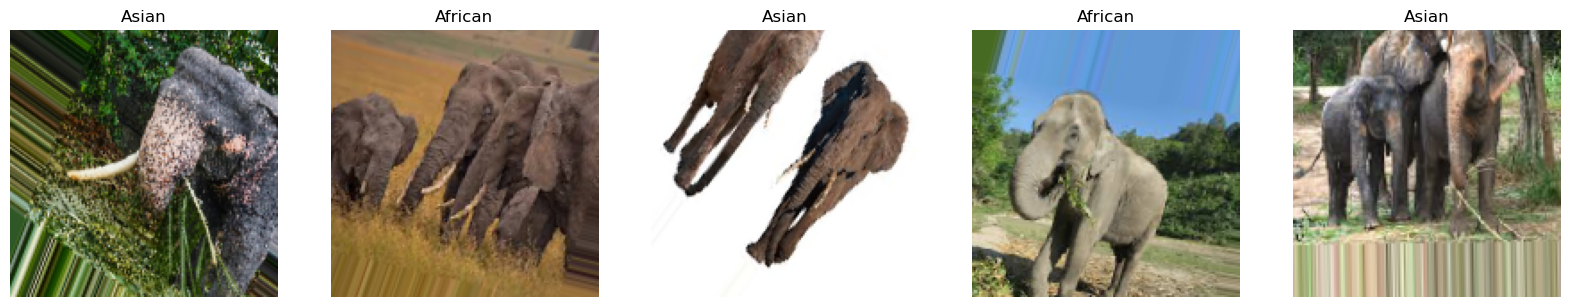

In [10]:
# Step 6: Visualize a Few Preprocessed Images

# Let's visualize some of the preprocessed images to check if everything is working correctly.

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Plot a few random images from the training set (first 5 images)
fig, axes = plt.subplots(1, 5, figsize=(20, 20))
for i in range(5):
    axes[i].imshow(images[i])  # Display the image
    axes[i].axis('off')        # Hide the axes
    axes[i].set_title('Asian' if labels[i] == 1 else 'African')  # Show the label

plt.show();

# This will display 5 images from the training set and their corresponding labels